# DARS Full Metrics and Baseline Comparison Notebook

This notebook uses the generated bot-student CSV pack plus the three context papers:

- `Executive Summary (1).pdf`
- `DARS_paper.pdf`
- `GATEWay_backend_logic.pdf`

The papers motivate an evaluation that is broader than a single accuracy score. DARS claims improvements through dynamic uncertainty decay, multi-signal performance quality, streak/momentum effects, graph-centrality routing, remediation, rapid-guess handling, and performance prediction. This notebook turns those claims into measurable checks.

Baselines included:
- **DARS**: probabilities derived from `DARS_rating_before_test` and question Elo.
- **Glicko-2**: uncertainty-aware rating baseline, updated once per adaptive test rating period.
- **Fixed Elo**: standard Elo baseline with constant `K=32`, updated after each attempted question.
- **Static starting rating**: no-learning baseline using each bot's starting rating throughout.

Outputs are saved into `datasets/dars/` as CSV files for report tables.


## Load and Validate CSV Dataset


In [41]:
students = pd.read_csv(BOT_STUDENTS_CSV)
responses_raw = pd.read_csv(TEST_RESPONSES_CSV)
sessions = pd.read_csv(TEST_SESSIONS_CSV)
snapshots = pd.read_csv(SNAPSHOTS_CSV)
interactions = pd.read_csv(INTERACTIONS_CSV)
graph = pd.read_csv(GRAPH_CSV)

responses = responses_raw.copy()
responses["timestamp_start"] = pd.to_datetime(responses["timestamp_start"], errors="coerce")
responses["timestamp_end"] = pd.to_datetime(responses["timestamp_end"], errors="coerce")

numeric_cols = [
    "question_order",
    "question_count_in_test",
    "attempted",
    "correctness",
    "score_awarded",
    "max_marks",
    "negative_marks",
    "response_time",
    "rapid_guess_flag",
    "rapid_guess_penalty",
    "streak_before",
    "streak_after",
    "DARS_rating_before_test",
    "DARS_rating_after_test",
    "test_rating_delta",
    "expected_success",
    "attempt_probability",
    "question_elo",
    "graph_hop_distance",
    "remediation_flag",
]
for col in numeric_cols:
    if col in responses:
        responses[col] = pd.to_numeric(responses[col], errors="coerce")

attempts = responses[responses["attempted"].eq(1)].copy()
attempts = attempts[attempts["correctness"].isin([0, 1])].copy()
attempts = attempts.dropna(
    subset=["timestamp_start", "DARS_rating_before_test", "DARS_rating_after_test", "question_elo", "correctness"]
)
attempts = attempts.merge(
    students[["user_id", "starting_rating", "persona"]],
    on="user_id",
    how="left",
    validate="many_to_one",
)
attempts = attempts.sort_values(["user_id", "timestamp_start", "test_id", "question_order"]).reset_index(drop=True)

sessions["timestamp_start"] = pd.to_datetime(sessions["timestamp_start"], errors="coerce")
sessions["timestamp_end"] = pd.to_datetime(sessions["timestamp_end"], errors="coerce")
for col in [
    "question_count",
    "questions_attempted",
    "correct_answers",
    "wrong_answers",
    "skipped_questions",
    "score",
    "max_score",
    "accuracy",
    "completion_rate",
    "DARS_rating_before",
    "DARS_rating_after",
    "rating_delta",
]:
    sessions[col] = pd.to_numeric(sessions[col], errors="coerce")

print(f"Bot students: {students['user_id'].nunique():,}")
print(f"All test-question rows: {len(responses):,}")
print(f"Attempted response rows used for model metrics: {len(attempts):,}")
print(f"Adaptive test sessions: {sessions['test_id'].nunique():,}")
print(f"Interaction rows: {len(interactions):,}")
print(f"Question graph edges: {len(graph):,}")

if attempts["starting_rating"].isna().any():
    raise ValueError("Some attempted responses did not merge to a bot student's starting rating.")

attempts.head()


Bot students: 220
All test-question rows: 77,850
Attempted response rows used for model metrics: 70,672
Adaptive test sessions: 1,683
Interaction rows: 55,000
Question graph edges: 2,140


,user_id,test_id,question_order,question_id,course_join_code,test_type,adaptive_mix_label,question_count_in_test,timestamp_start,timestamp_end,...,topic,topic_id,subject_id,difficulty_label,question_elo,graph_hop_distance,remediation_flag,recommendation_source,starting_rating,persona
0,stu_fte455_001,stu_fte455_001_adaptive_mix_01,1,la-32,FTE455,adaptive_mix,Adaptive test mix (40),40,2026-02-01 10:13:41.718000+00:00,2026-02-01 10:15:40.718000+00:00,...,Eigenvalues & Eigenvectors,la-eigenvalues,linear-algebra,Hard,1360,0,0,fallback,1331,steady_improver
1,stu_fte455_001,stu_fte455_001_adaptive_mix_01,2,la-33,FTE455,adaptive_mix,Adaptive test mix (40),40,2026-02-01 10:15:40.718000+00:00,2026-02-01 10:18:10.718000+00:00,...,Eigenvalues & Eigenvectors,la-eigenvalues,linear-algebra,Hard,1360,1,0,Graph route,1331,steady_improver
2,stu_fte455_001,stu_fte455_001_adaptive_mix_01,3,la-43,FTE455,adaptive_mix,Adaptive test mix (40),40,2026-02-01 10:18:10.718000+00:00,2026-02-01 10:19:59.718000+00:00,...,Eigenvalues & Eigenvectors,la-eigenvalues,linear-algebra,Hard,1360,1,1,Graph route,1331,steady_improver
3,stu_fte455_001,stu_fte455_001_adaptive_mix_01,5,la-4,FTE455,adaptive_mix,Adaptive test mix (40),40,2026-02-01 10:20:36.718000+00:00,2026-02-01 10:22:52.718000+00:00,...,Eigenvalues & Eigenvectors,la-eigenvalues,linear-algebra,Hard,1360,1,0,Graph route,1331,steady_improver
4,stu_fte455_001,stu_fte455_001_adaptive_mix_01,7,mock5-q28,FTE455,adaptive_mix,Adaptive test mix (40),40,2026-02-01 10:23:05.718000+00:00,2026-02-01 10:24:31.718000+00:00,...,Eigenvalues & Eigenvectors,la-eigenvalues,linear-algebra,Medium,1350,1,1,Graph route,1331,steady_improver


## Metric Helpers


In [42]:
def elo_expected(rating: float, item_rating: float) -> float:
    return 1.0 / (1.0 + 10.0 ** ((float(item_rating) - float(rating)) / 400.0))


def clip_prob(values):
    return np.clip(np.asarray(values, dtype=float), 1e-6, 1 - 1e-6)


def brier_score(y_true, y_prob) -> float:
    y = np.asarray(y_true, dtype=float)
    p = clip_prob(y_prob)
    return float(np.mean((p - y) ** 2))


def rmse_prob(y_true, y_prob) -> float:
    return float(np.sqrt(brier_score(y_true, y_prob)))


def log_loss(y_true, y_prob) -> float:
    y = np.asarray(y_true, dtype=float)
    p = clip_prob(y_prob)
    return float(-np.mean(y * np.log(p) + (1 - y) * np.log(1 - p)))


def accuracy_at_half(y_true, y_prob) -> float:
    y = np.asarray(y_true, dtype=int)
    p = np.asarray(y_prob, dtype=float)
    return float(np.mean((p >= 0.5).astype(int) == y))


def roc_auc_score_binary(y_true, y_prob) -> float:
    y = np.asarray(y_true, dtype=int)
    p = np.asarray(y_prob, dtype=float)
    positives = y == 1
    negatives = y == 0
    n_pos = int(positives.sum())
    n_neg = int(negatives.sum())
    if n_pos == 0 or n_neg == 0:
        return float("nan")

    order = np.argsort(p)
    sorted_p = p[order]
    ranks = np.empty_like(sorted_p, dtype=float)
    start = 0
    while start < len(sorted_p):
        end = start + 1
        while end < len(sorted_p) and sorted_p[end] == sorted_p[start]:
            end += 1
        ranks[start:end] = (start + 1 + end) / 2.0
        start = end

    original_ranks = np.empty_like(ranks)
    original_ranks[order] = ranks
    rank_sum_pos = original_ranks[positives].sum()
    return float((rank_sum_pos - n_pos * (n_pos + 1) / 2.0) / (n_pos * n_neg))


def calibration_table(frame: pd.DataFrame, prob_col: str, bins: int = 10) -> pd.DataFrame:
    temp = frame[[prob_col, "correctness"]].dropna().copy()
    temp["bin"] = pd.cut(temp[prob_col], bins=np.linspace(0, 1, bins + 1), include_lowest=True)
    return (
        temp.groupby("bin", observed=True)
        .agg(
            mean_predicted=(prob_col, "mean"),
            actual_accuracy=("correctness", "mean"),
            n=("correctness", "size"),
        )
        .reset_index()
    )


def expected_calibration_error(frame: pd.DataFrame, prob_col: str, bins: int = 10) -> float:
    cal = calibration_table(frame, prob_col, bins=bins)
    total = cal["n"].sum()
    if total == 0:
        return float("nan")
    return float((cal["n"] * (cal["mean_predicted"] - cal["actual_accuracy"]).abs()).sum() / total)


def max_calibration_error(frame: pd.DataFrame, prob_col: str, bins: int = 10) -> float:
    cal = calibration_table(frame, prob_col, bins=bins)
    if cal.empty:
        return float("nan")
    return float((cal["mean_predicted"] - cal["actual_accuracy"]).abs().max())


def metric_row(name: str, frame: pd.DataFrame, prob_col: str) -> dict:
    clean = frame[["correctness", prob_col]].dropna()
    y = clean["correctness"].astype(float).to_numpy()
    p = clean[prob_col].astype(float).to_numpy()
    return {
        "model": name,
        "n": len(clean),
        "brier": brier_score(y, p),
        "rmse": rmse_prob(y, p),
        "log_loss": log_loss(y, p),
        "accuracy_at_0_5": accuracy_at_half(y, p),
        "roc_auc": roc_auc_score_binary(y, p),
        "ece_10_bins": expected_calibration_error(clean, prob_col, bins=10),
        "mce_10_bins": max_calibration_error(clean, prob_col, bins=10),
        "mean_predicted_correct": float(np.mean(p)),
        "actual_accuracy": float(np.mean(y)),
    }


## Baseline Rating Models


In [43]:
def rating_to_mu(rating: float) -> float:
    return (float(rating) - 1500.0) / GLICKO2_SCALE


def rd_to_phi(rd: float) -> float:
    return float(rd) / GLICKO2_SCALE


def mu_to_rating(mu: float) -> float:
    return 1500.0 + GLICKO2_SCALE * float(mu)


def phi_to_rd(phi: float) -> float:
    return GLICKO2_SCALE * float(phi)


def glicko2_g(phi: float) -> float:
    return 1.0 / math.sqrt(1.0 + 3.0 * phi**2 / math.pi**2)


def glicko2_expected(mu: float, opp_mu: float, opp_phi: float) -> float:
    return 1.0 / (1.0 + math.exp(-glicko2_g(opp_phi) * (mu - opp_mu)))


@dataclass
class Glicko2State:
    rating: float
    rd: float = GLICKO2_INITIAL_RD
    volatility: float = GLICKO2_INITIAL_VOL


def glicko2_prediction(player: Glicko2State, item_rating: float, item_rd: float = ITEM_RD) -> float:
    return glicko2_expected(rating_to_mu(player.rating), rating_to_mu(item_rating), rd_to_phi(item_rd))


def _volatility_f(x: float, delta: float, phi: float, v: float, a: float, tau: float) -> float:
    exp_x = math.exp(x)
    numerator = exp_x * (delta**2 - phi**2 - v - exp_x)
    denominator = 2.0 * (phi**2 + v + exp_x) ** 2
    return numerator / denominator - (x - a) / (tau**2)


def glicko2_update_period(
    player: Glicko2State,
    item_ratings: list[float],
    outcomes: list[float],
    item_rd: float = ITEM_RD,
    tau: float = GLICKO2_TAU,
    epsilon: float = EPSILON,
) -> Glicko2State:
    if not item_ratings:
        phi = rd_to_phi(player.rd)
        phi_star = math.sqrt(phi**2 + player.volatility**2)
        return Glicko2State(player.rating, phi_to_rd(phi_star), player.volatility)

    mu = rating_to_mu(player.rating)
    phi = rd_to_phi(player.rd)
    sigma = player.volatility
    opp_mus = [rating_to_mu(r) for r in item_ratings]
    opp_phi = rd_to_phi(item_rd)
    gs = [glicko2_g(opp_phi) for _ in opp_mus]
    es = [glicko2_expected(mu, opp_mu, opp_phi) for opp_mu in opp_mus]

    v_inv = sum((g**2) * e * (1 - e) for g, e in zip(gs, es))
    if v_inv <= 0:
        return player
    v = 1.0 / v_inv
    delta = v * sum(g * (s - e) for g, s, e in zip(gs, outcomes, es))

    a = math.log(sigma**2)
    if delta**2 > phi**2 + v:
        b = math.log(delta**2 - phi**2 - v)
    else:
        k = 1
        while _volatility_f(a - k * tau, delta, phi, v, a, tau) < 0:
            k += 1
        b = a - k * tau

    f_a = _volatility_f(a, delta, phi, v, a, tau)
    f_b = _volatility_f(b, delta, phi, v, a, tau)
    while abs(b - a) > epsilon:
        c = a + (a - b) * f_a / (f_b - f_a)
        f_c = _volatility_f(c, delta, phi, v, a, tau)
        if f_c * f_b < 0:
            a = b
            f_a = f_b
        else:
            f_a /= 2.0
        b = c
        f_b = f_c

    new_sigma = math.exp(a / 2.0)
    phi_star = math.sqrt(phi**2 + new_sigma**2)
    new_phi = 1.0 / math.sqrt((1.0 / phi_star**2) + (1.0 / v))
    new_mu = mu + new_phi**2 * sum(g * (s - e) for g, s, e in zip(gs, outcomes, es))

    return Glicko2State(
        rating=float(mu_to_rating(new_mu)),
        rd=float(max(30.0, min(350.0, phi_to_rd(new_phi)))),
        volatility=float(new_sigma),
    )


def fixed_elo_update(rating: float, item_rating: float, outcome: float, k: float = FIXED_ELO_K) -> float:
    return float(rating + k * (outcome - elo_expected(rating, item_rating)))


## Replay DARS, Glicko-2, Fixed Elo, and Static Baselines


In [44]:
work = attempts.copy()
work["dars_prob"] = [
    elo_expected(rating, item)
    for rating, item in zip(work["DARS_rating_before_test"], work["question_elo"])
]
work["static_start_prob"] = [
    elo_expected(rating, item)
    for rating, item in zip(work["starting_rating"], work["question_elo"])
]

glicko_records = []
elo_records = []
final_glicko_states = {}
final_elo_ratings = {}

for user_id, student_rows in work.groupby("user_id", sort=False):
    start_rating = float(student_rows["starting_rating"].iloc[0])
    glicko_state = Glicko2State(rating=start_rating)
    elo_rating = start_rating

    for test_id, period in student_rows.groupby("test_id", sort=False):
        period = period.sort_values(["timestamp_start", "question_order"])

        glicko_before = glicko_state
        glicko_probs = [glicko2_prediction(glicko_state, item_rating) for item_rating in period["question_elo"].astype(float)]
        glicko_after = glicko2_update_period(
            glicko_state,
            period["question_elo"].astype(float).tolist(),
            period["correctness"].astype(float).tolist(),
        )

        for row_index, probability in zip(period.index, glicko_probs):
            glicko_records.append(
                {
                    "row_index": row_index,
                    "glicko2_prob": probability,
                    "glicko2_rating_before_period": glicko_before.rating,
                    "glicko2_rd_before_period": glicko_before.rd,
                    "glicko2_vol_before_period": glicko_before.volatility,
                    "glicko2_rating_after_period": glicko_after.rating,
                    "glicko2_rd_after_period": glicko_after.rd,
                    "glicko2_vol_after_period": glicko_after.volatility,
                }
            )
        glicko_state = glicko_after

        for row_index, row in period.iterrows():
            elo_before = elo_rating
            prob = elo_expected(elo_before, row["question_elo"])
            elo_rating = fixed_elo_update(elo_before, row["question_elo"], row["correctness"])
            elo_records.append(
                {
                    "row_index": row_index,
                    "fixed_elo_prob": prob,
                    "fixed_elo_rating_before": elo_before,
                    "fixed_elo_rating_after": elo_rating,
                }
            )

    final_glicko_states[user_id] = glicko_state
    final_elo_ratings[user_id] = elo_rating

work = work.join(pd.DataFrame(glicko_records).set_index("row_index"), how="left")
work = work.join(pd.DataFrame(elo_records).set_index("row_index"), how="left")

def logit(prob):
    prob = clip_prob(prob)
    return np.log(prob / (1 - prob))


def sigmoid(values):
    return 1.0 / (1.0 + np.exp(-np.clip(values, -30, 30)))


def build_dars_plus_features(frame: pd.DataFrame, reference_columns: list[str] | None = None):
    parts = []
    names = []

    def add(name: str, values):
        names.append(name)
        parts.append(np.asarray(values, dtype=float))

    add("intercept", np.ones(len(frame)))
    add("dars_logit", logit(frame["dars_prob"].to_numpy(dtype=float)))
    add("rating_gap_scaled", (frame["DARS_rating_before_test"] - frame["question_elo"]) / 400.0)
    add("streak_before_scaled", frame["streak_before"].fillna(0).clip(-6, 6) / 6.0)
    add("remediation_flag", frame["remediation_flag"].fillna(0))
    add("graph_hop_scaled", frame["graph_hop_distance"].fillna(2).clip(0, 4) / 4.0)
    add("question_count_scaled", frame["question_count_in_test"].fillna(frame["question_count_in_test"].median()) / 65.0)

    categorical_cols = ["difficulty_label", "recommendation_source", "momentum_before"]
    if reference_columns is None:
        for col in categorical_cols:
            for value in sorted(frame[col].dropna().astype(str).unique()):
                add(f"{col}={value}", frame[col].astype(str).eq(value).astype(float))
    else:
        existing = set(names)
        for full_name in reference_columns:
            if full_name in existing:
                continue
            if "=" not in full_name:
                continue
            col, value = full_name.split("=", 1)
            add(full_name, frame[col].astype(str).eq(value).astype(float))

    return np.vstack(parts).T, names


def fit_logistic_model(X, y, iterations=2500, learning_rate=0.25, l2=0.005):
    weights = np.zeros(X.shape[1])
    for _ in range(iterations):
        pred = sigmoid(X @ weights)
        penalty = weights.copy()
        penalty[0] = 0.0
        gradient = X.T @ (pred - y) / len(y) + l2 * penalty
        weights -= learning_rate * gradient
    return weights


rng = np.random.default_rng(20260515)
unique_users = work["user_id"].drop_duplicates().to_numpy()
rng.shuffle(unique_users)
train_user_count = int(0.70 * len(unique_users))
train_users = set(unique_users[:train_user_count])
work["evaluation_split"] = np.where(work["user_id"].isin(train_users), "train", "test")

X_all_raw, feature_names = build_dars_plus_features(work)
train_mask = work["evaluation_split"].eq("train").to_numpy()
test_mask = ~train_mask
y_all = work["correctness"].to_numpy(dtype=float)

feature_mean = X_all_raw[train_mask].mean(axis=0)
feature_std = X_all_raw[train_mask].std(axis=0) + 1e-9
feature_mean[0] = 0.0
feature_std[0] = 1.0
X_all = (X_all_raw - feature_mean) / feature_std

dars_plus_weights = fit_logistic_model(X_all[train_mask], y_all[train_mask])
work["dars_plus_prob"] = sigmoid(X_all @ dars_plus_weights)

MODEL_PROBS = {
    "DARS+ calibrated": "dars_plus_prob",
    "DARS": "dars_prob",
    "Glicko-2": "glicko2_prob",
    "Fixed Elo K=32": "fixed_elo_prob",
    "Static start": "static_start_prob",
}

print(f"DARS+ trained on {train_mask.sum():,} responses from {train_user_count} students.")
print(f"Main model metrics below are evaluated on {test_mask.sum():,} held-out responses from {len(unique_users) - train_user_count} students.")

dars_plus_coefficients = pd.DataFrame(
    {"feature": feature_names, "coefficient": dars_plus_weights}
).assign(abs_coefficient=lambda df: df["coefficient"].abs()).sort_values("abs_coefficient", ascending=False)

display(dars_plus_coefficients.head(15).round(4))
work[[*MODEL_PROBS.values(), "evaluation_split"]].describe(include="all").round(4)


DARS+ trained on 49,340 responses from 154 students.
Main model metrics below are evaluated on 21,332 held-out responses from 66 students.


,feature,coefficient,abs_coefficient
0,intercept,0.4961,0.4961
7,difficulty_label=Easy,0.2309,0.2309
8,difficulty_label=Hard,-0.1986,0.1986
1,dars_logit,0.0947,0.0947
2,rating_gap_scaled,0.0947,0.0947
12,momentum_before=cold,-0.0349,0.0349
13,momentum_before=hot,0.0341,0.0341
3,streak_before_scaled,0.0305,0.0305
4,remediation_flag,0.0173,0.0173
9,difficulty_label=Medium,-0.0162,0.0162


,dars_plus_prob,dars_prob,glicko2_prob,fixed_elo_prob,static_start_prob,evaluation_split
count,70672.0000,70672.0000,70672.0000,70672.0000,70672.0000,70672
unique,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,train
freq,NaN,NaN,NaN,NaN,NaN,49340
mean,0.6161,0.6612,0.6137,0.6186,0.6553,NaN
std,0.1075,0.1735,0.1502,0.1465,0.1693,NaN
min,0.3162,0.0801,0.1093,0.1078,0.1014,NaN
25%,0.5521,0.5273,0.5080,0.5183,0.5302,NaN
50%,0.6120,0.6813,0.6213,0.6267,0.6738,NaN
75%,0.6721,0.8038,0.7258,0.7278,0.7946,NaN


## Overall Predictive Metrics


In [45]:
eval_frame = work[work["evaluation_split"].eq("test")].copy()

overall_metrics = pd.DataFrame(
    [metric_row(model, eval_frame, prob_col) for model, prob_col in MODEL_PROBS.items()]
).sort_values("brier")
overall_metrics.insert(1, "evaluation_split", "held_out_students")

overall_metrics.to_csv(SUMMARY_OUTPUT_CSV, index=False)
overall_metrics.round(5)


,model,evaluation_split,n,brier,rmse,log_loss,accuracy_at_0_5,roc_auc,ece_10_bins,mce_10_bins,mean_predicted_correct,actual_accuracy
0,DARS+ calibrated,held_out_students,21332,0.22445,0.47376,0.63930,0.63060,0.63185,0.00623,0.01176,0.61920,0.61551
2,Glicko-2,held_out_students,21332,0.23084,0.48045,0.65457,0.61959,0.61546,0.04677,0.17367,0.61486,0.61551
3,Fixed Elo K=32,held_out_students,21332,0.23120,0.48083,0.65513,0.61860,0.61179,0.04745,0.34681,0.61971,0.61551
4,Static start,held_out_students,21332,0.23817,0.48802,0.67728,0.61687,0.60854,0.08731,0.16709,0.66557,0.61551
1,DARS,held_out_students,21332,0.23888,0.48876,0.68216,0.61907,0.61050,0.09177,0.16801,0.66802,0.61551


## Bootstrap Confidence Intervals for Model Metrics


In [46]:
def bootstrap_metric_ci(frame: pd.DataFrame, model_probs: dict[str, str], metric_fn, metric_name: str, n_boot=100, seed=20260515):
    rng = np.random.default_rng(seed)
    n_rows = len(frame)
    y_all = frame["correctness"].to_numpy(dtype=float)
    rows = []
    for model, prob_col in model_probs.items():
        p_all = frame[prob_col].to_numpy(dtype=float)
        values = []
        for _ in range(n_boot):
            idx = rng.integers(0, n_rows, size=n_rows)
            values.append(metric_fn(y_all[idx], p_all[idx]))
        values = np.asarray(values, dtype=float)
        rows.append(
            {
                "model": model,
                "metric": metric_name,
                "mean": float(np.nanmean(values)),
                "ci_low_2_5": float(np.nanpercentile(values, 2.5)),
                "ci_high_97_5": float(np.nanpercentile(values, 97.5)),
            }
        )
    return pd.DataFrame(rows)


bootstrap_ci = pd.concat(
    [
        bootstrap_metric_ci(eval_frame, MODEL_PROBS, brier_score, "brier", n_boot=100, seed=1),
        bootstrap_metric_ci(eval_frame, MODEL_PROBS, log_loss, "log_loss", n_boot=100, seed=2),
        bootstrap_metric_ci(eval_frame, MODEL_PROBS, roc_auc_score_binary, "roc_auc", n_boot=100, seed=3),
    ],
    ignore_index=True,
)
bootstrap_ci.to_csv(BOOTSTRAP_OUTPUT_CSV, index=False)
bootstrap_ci.round(5)


,model,metric,mean,ci_low_2_5,ci_high_97_5
0,DARS+ calibrated,brier,0.22453,0.22233,0.22646
1,DARS,brier,0.23910,0.23643,0.24155
2,Glicko-2,brier,0.23068,0.22865,0.23271
3,Fixed Elo K=32,brier,0.23133,0.22903,0.23368
4,Static start,brier,0.23818,0.23556,0.24124
5,DARS+ calibrated,log_loss,0.63990,0.63569,0.64405
6,DARS,log_loss,0.68170,0.67399,0.68960
7,Glicko-2,log_loss,0.65466,0.64988,0.66051
8,Fixed Elo K=32,log_loss,0.65533,0.65071,0.66176
9,Static start,log_loss,0.67753,0.67121,0.68434


## Calibration Curves and Reliability Metrics


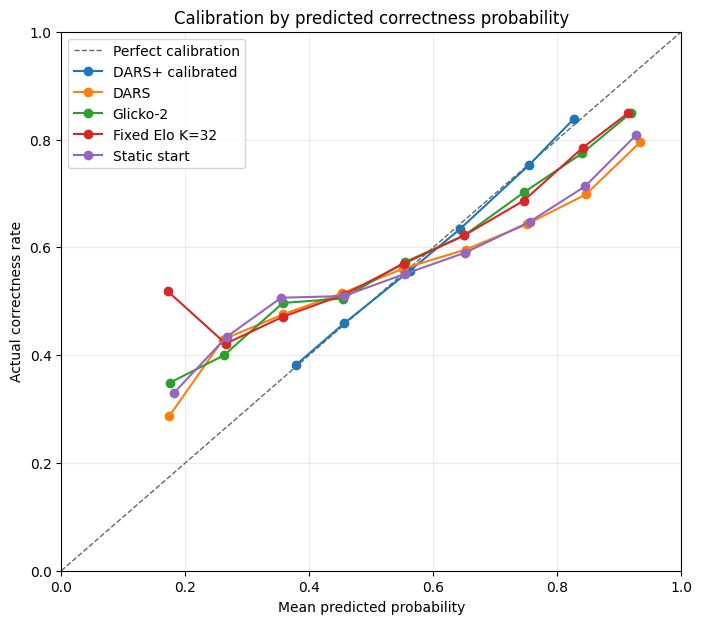

,model,ece_10_bins,mce_10_bins,mean_predicted_correct,actual_accuracy
0,DARS+ calibrated,0.00623,0.01176,0.61920,0.61551
2,Glicko-2,0.04677,0.17367,0.61486,0.61551
3,Fixed Elo K=32,0.04745,0.34681,0.61971,0.61551
4,Static start,0.08731,0.16709,0.66557,0.61551
1,DARS,0.09177,0.16801,0.66802,0.61551


In [47]:
fig, ax = plt.subplots(figsize=(8, 7))
ax.plot([0, 1], [0, 1], color="#666666", linestyle="--", linewidth=1, label="Perfect calibration")

calibration_tables = []
for model, prob_col in MODEL_PROBS.items():
    cal = calibration_table(eval_frame, prob_col, bins=10).assign(model=model)
    calibration_tables.append(cal)
    ax.plot(cal["mean_predicted"], cal["actual_accuracy"], marker="o", label=model)

ax.set_title("Calibration by predicted correctness probability")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Actual correctness rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()
plt.show()

calibration_metrics = overall_metrics[["model", "ece_10_bins", "mce_10_bins", "mean_predicted_correct", "actual_accuracy"]]
calibration_metrics.round(5)


## Segment Comparisons: Persona, Difficulty, Momentum, Routing, Remediation


In [48]:
segment_frames = []
segments = [
    "persona",
    "difficulty_label",
    "question_count_in_test",
    "recommendation_source",
    "remediation_flag",
    "rapid_guess_flag",
    "momentum_before",
    "momentum_after",
]

for segment in segments:
    rows = []
    for value, frame in eval_frame.groupby(segment, dropna=False):
        if len(frame) < 25:
            continue
        base = {
            "segment": segment,
            "value": value,
            "n": len(frame),
            "actual_accuracy": float(frame["correctness"].mean()),
            "avg_response_time": float(frame["response_time"].mean()),
            "rapid_guess_rate": float(frame["rapid_guess_flag"].mean()),
            "avg_dars_delta": float((frame["DARS_rating_after_test"] - frame["DARS_rating_before_test"]).mean()),
        }
        for model, prob_col in MODEL_PROBS.items():
            metrics = metric_row(model, frame, prob_col)
            base[f"{model}_brier"] = metrics["brier"]
            base[f"{model}_log_loss"] = metrics["log_loss"]
            base[f"{model}_auc"] = metrics["roc_auc"]
        rows.append(base)
    segment_frames.append(pd.DataFrame(rows))

segment_metrics = pd.concat(segment_frames, ignore_index=True)
segment_metrics.to_csv(SEGMENT_OUTPUT_CSV, index=False)
segment_metrics.sort_values(["segment", "value"]).round(4)


,segment,value,n,actual_accuracy,avg_response_time,rapid_guess_rate,avg_dars_delta,DARS+ calibrated_brier,DARS+ calibrated_log_loss,DARS+ calibrated_auc,...,DARS_auc,Glicko-2_brier,Glicko-2_log_loss,Glicko-2_auc,Fixed Elo K=32_brier,Fixed Elo K=32_log_loss,Fixed Elo K=32_auc,Static start_brier,Static start_log_loss,Static start_auc
5,difficulty_label,Easy,4107,0.7862,50.4451,0.0460,9.8011,0.1658,0.5123,0.5828,...,0.5740,0.1680,0.5184,0.5754,0.1685,0.5191,0.5709,0.1718,0.5364,0.5642
6,difficulty_label,Hard,4523,0.4795,130.2483,0.0000,1.2447,0.2467,0.6865,0.5578,...,0.5583,0.2584,0.7133,0.5466,0.2584,0.7129,0.5433,0.2664,0.7346,0.5544
7,difficulty_label,Medium,12702,0.6087,90.0746,0.0000,5.6867,0.2355,0.6636,0.5619,...,0.5657,0.2413,0.6777,0.5551,0.2418,0.6786,0.5487,0.2496,0.7024,0.5577
21,momentum_after,cold,5387,0.4726,91.7058,0.0204,-0.7195,0.2462,0.6859,0.6379,...,0.5843,0.2562,0.7095,0.5803,0.2468,0.6890,0.6305,0.2646,0.7350,0.6241
22,momentum_after,hot,2076,1.0000,71.5491,0.0034,20.4080,0.0927,0.3493,NaN,...,NaN,0.0927,0.3398,NaN,0.0762,0.3011,NaN,0.0795,0.2950,NaN
23,momentum_after,steady,13869,0.6135,93.5801,0.0052,5.7411,0.2357,0.6646,0.5665,...,0.5583,0.2416,0.6804,0.5696,0.2483,0.6950,0.5366,0.2517,0.7121,0.5615
18,momentum_before,cold,5381,0.5839,88.8825,0.0204,-0.6579,0.2327,0.6576,0.6221,...,0.6002,0.2407,0.6752,0.5990,0.2406,0.6756,0.5984,0.2422,0.6833,0.6057
19,momentum_before,hot,2076,0.7129,78.7760,0.0034,20.3054,0.1937,0.5724,0.6488,...,0.6271,0.1961,0.5799,0.6425,0.1977,0.5838,0.6383,0.2032,0.6055,0.6252
20,momentum_before,steady,13875,0.6132,93.5929,0.0052,5.7298,0.2258,0.6422,0.6261,...,0.6026,0.2322,0.6578,0.6095,0.2325,0.6579,0.6041,0.2418,0.6857,0.5983
0,persona,fast_but_careless,4327,0.5567,74.5027,0.0430,-6.6094,0.2377,0.6685,0.6217,...,0.5938,0.2431,0.6807,0.5998,0.2446,0.6841,0.5931,0.2526,0.7102,0.6037


## Rating Dynamics and Convergence Checks


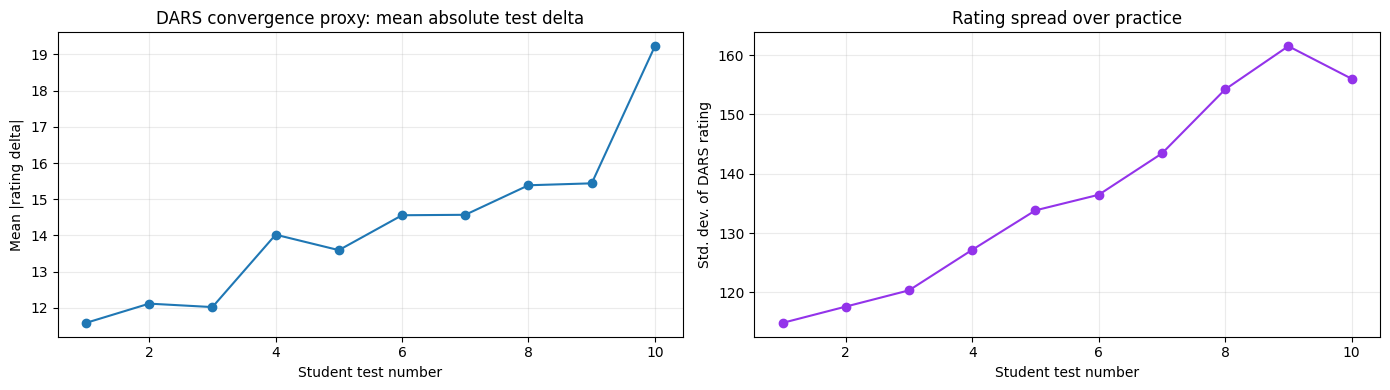

,test_number,tests,mean_abs_dars_delta,median_abs_dars_delta,mean_rating,rating_std,mean_accuracy
0,1,220,11.586,9.0,1520.105,114.853,0.553
1,2,220,12.118,11.0,1522.741,117.603,0.599
2,3,220,12.023,10.0,1524.927,120.342,0.598
3,4,220,14.023,11.0,1528.995,127.174,0.611
4,5,220,13.595,11.0,1535.382,133.827,0.627
5,6,186,14.559,12.0,1541.618,136.453,0.627
6,7,154,14.571,12.0,1550.468,143.419,0.640
7,8,124,15.387,14.0,1558.919,154.223,0.654
8,9,84,15.440,14.0,1565.214,161.512,0.649
9,10,35,19.229,18.0,1572.000,156.026,0.674


In [49]:
session_enriched = sessions.merge(
    students[["user_id", "persona", "starting_rating"]],
    on="user_id",
    how="left",
    validate="many_to_one",
).sort_values(["user_id", "timestamp_start"])
session_enriched["test_number"] = session_enriched.groupby("user_id").cumcount() + 1
session_enriched["abs_dars_delta"] = session_enriched["rating_delta"].abs()
session_enriched["dars_rating_change_from_start"] = session_enriched["DARS_rating_after"] - session_enriched["starting_rating"]

convergence_by_test = (
    session_enriched.groupby("test_number")
    .agg(
        tests=("test_id", "size"),
        mean_abs_dars_delta=("abs_dars_delta", "mean"),
        median_abs_dars_delta=("abs_dars_delta", "median"),
        mean_rating=("DARS_rating_after", "mean"),
        rating_std=("DARS_rating_after", "std"),
        mean_accuracy=("accuracy", "mean"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(convergence_by_test["test_number"], convergence_by_test["mean_abs_dars_delta"], marker="o")
axes[0].set_title("DARS convergence proxy: mean absolute test delta")
axes[0].set_xlabel("Student test number")
axes[0].set_ylabel("Mean |rating delta|")

axes[1].plot(convergence_by_test["test_number"], convergence_by_test["rating_std"], marker="o", color="#9333ea")
axes[1].set_title("Rating spread over practice")
axes[1].set_xlabel("Student test number")
axes[1].set_ylabel("Std. dev. of DARS rating")
plt.tight_layout()
plt.show()

convergence_by_test.round(3)


## Graph Routing Metrics


In [50]:
edge_counts = graph["edge_type"].value_counts().rename_axis("edge_type").reset_index(name="edges")

route_metrics = (
    work.groupby(["recommendation_source", "graph_hop_distance"], dropna=False)
    .agg(
        n=("correctness", "size"),
        actual_accuracy=("correctness", "mean"),
        mean_dars_prob=("dars_prob", "mean"),
        mean_response_time=("response_time", "mean"),
        rapid_guess_rate=("rapid_guess_flag", "mean"),
        remediation_rate=("remediation_flag", "mean"),
        mean_question_elo=("question_elo", "mean"),
    )
    .reset_index()
)

question_route_coverage = (
    work.groupby("recommendation_source")
    .agg(
        responses=("question_id", "size"),
        unique_questions=("question_id", "nunique"),
        unique_topics=("topic", "nunique"),
        accuracy=("correctness", "mean"),
    )
    .reset_index()
)

route_metrics.to_csv(GRAPH_OUTPUT_CSV, index=False)

display(edge_counts)
display(question_route_coverage.round(4))
route_metrics.round(4)


,edge_type,edges
0,same-topic,1576
1,cross-domain,359
2,prerequisite,205


,recommendation_source,responses,unique_questions,unique_topics,accuracy
0,Graph route,67708,802,22,0.6201
1,fallback,2964,425,22,0.4983


,recommendation_source,graph_hop_distance,n,actual_accuracy,mean_dars_prob,mean_response_time,rapid_guess_rate,remediation_rate,mean_question_elo
0,Graph route,1,67708,0.6201,0.6677,90.3249,0.0080,0.3778,1388.0943
1,fallback,0,190,0.4526,0.4573,118.5053,0.0000,0.0000,1550.8684
2,fallback,2,1416,0.4972,0.5181,112.6271,0.0028,0.1363,1508.0614
3,fallback,3,1358,0.5059,0.5177,112.2688,0.0015,0.1510,1507.7246


## Question Knowledge Graph Visualization


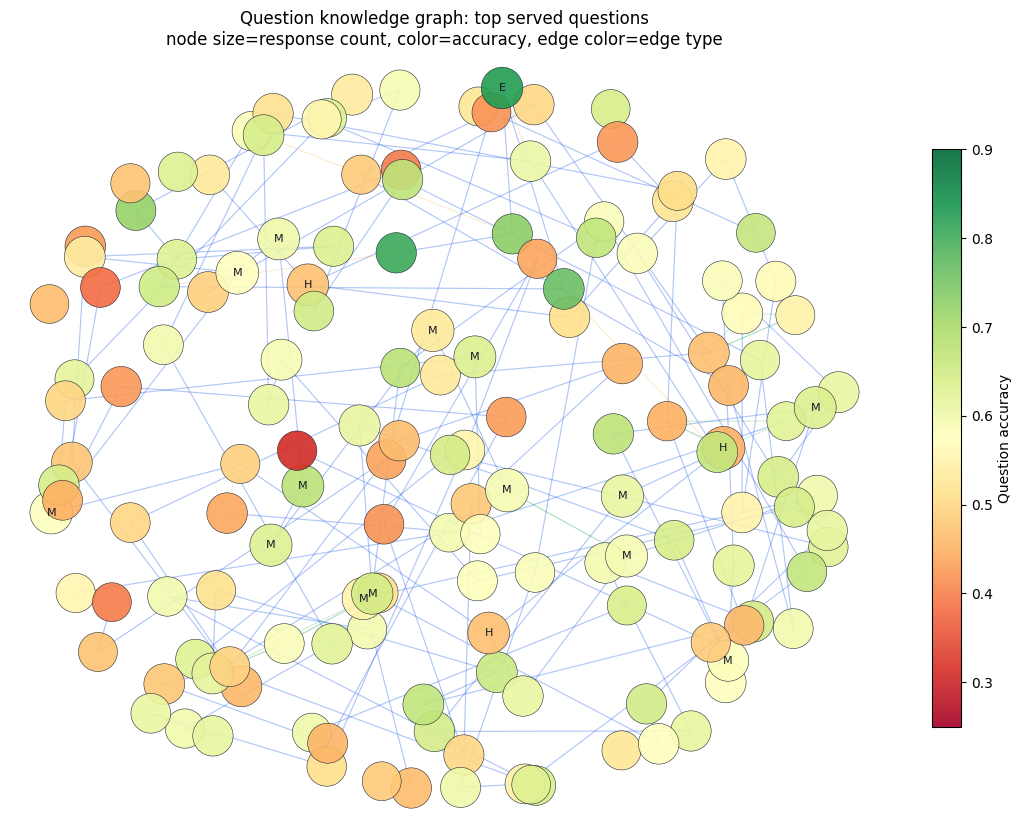

,edge_type,visible_edges
0,same-topic,258
1,cross-domain,17
2,prerequisite,4


,question_id,in_degree,out_degree,responses,accuracy,avg_elo,topic,difficulty
80,mock3-q36,3,3,179.0,0.5922,1450.0,Search Algorithms,Medium
30,ai-43,3,2,175.0,0.4457,1500.0,Propositional & Predicate Logic,Hard
29,ai-42,2,2,174.0,0.5747,1400.0,Propositional & Predicate Logic,Medium
31,ai-46,2,2,172.0,0.5756,1400.0,Propositional & Predicate Logic,Medium
5,ai-10,2,2,170.0,0.6118,1400.0,Search Algorithms,Medium
82,mock3-q49,2,2,170.0,0.5294,1450.0,Search Algorithms,Medium
84,mock3-q54,2,2,169.0,0.5503,1475.0,Normalization,Medium
85,mock3-q65,2,2,169.0,0.6331,1450.0,Search Algorithms,Medium
79,mock2-q54,3,3,168.0,0.5893,1475.0,Normalization,Medium
32,ai-6,2,2,167.0,0.6766,1450.0,Search Algorithms,Medium


In [51]:
question_stats = (
    work.groupby("question_id")
    .agg(
        responses=("correctness", "size"),
        accuracy=("correctness", "mean"),
        avg_elo=("question_elo", "mean"),
        topic=("topic", lambda values: values.mode().iloc[0] if not values.mode().empty else values.iloc[0]),
        difficulty=("difficulty_label", lambda values: values.mode().iloc[0] if not values.mode().empty else values.iloc[0]),
    )
    .reset_index()
)

top_questions = set(question_stats.sort_values("responses", ascending=False).head(150)["question_id"])
graph_view_edges = graph[graph["source_q"].isin(top_questions) & graph["target_q"].isin(top_questions)].copy()

if NETWORKX_AVAILABLE and not graph_view_edges.empty:
    G = nx.DiGraph()
    for row in question_stats[question_stats["question_id"].isin(top_questions)].itertuples(index=False):
        G.add_node(
            row.question_id,
            responses=float(row.responses),
            accuracy=float(row.accuracy),
            avg_elo=float(row.avg_elo),
            topic=row.topic,
            difficulty=row.difficulty,
        )
    for row in graph_view_edges.itertuples(index=False):
        G.add_edge(row.source_q, row.target_q, edge_type=row.edge_type, weight=float(row.weight))

    pos = nx.spring_layout(G, seed=7, k=0.42, iterations=70, weight="weight")
    node_sizes = [80 + 5.0 * G.nodes[node]["responses"] for node in G.nodes]
    node_colors = [G.nodes[node]["accuracy"] for node in G.nodes]
    edge_color_map = {
        "same-topic": "#2563eb",
        "prerequisite": "#f59e0b",
        "cross-domain": "#16a34a",
        "subject-flow": "#f59e0b",
        "subject-bridge": "#16a34a",
    }
    edge_colors = [edge_color_map.get(G.edges[edge]["edge_type"], "#94a3b8") for edge in G.edges]

    fig, ax = plt.subplots(figsize=(14, 10))
    for (source, target), color in zip(G.edges, edge_colors):
        x0, y0 = pos[source]
        x1, y1 = pos[target]
        ax.plot([x0, x1], [y0, y1], color=color, alpha=0.20, linewidth=0.8, zorder=1)

    node_xy = np.asarray([pos[node] for node in G.nodes])
    nodes = ax.scatter(
        node_xy[:, 0],
        node_xy[:, 1],
        s=node_sizes,
        c=node_colors,
        cmap="RdYlGn",
        vmin=0.25,
        vmax=0.9,
        alpha=0.9,
        linewidths=0.4,
        edgecolors="#0f172a",
        zorder=2,
    )
    label_nodes = question_stats[question_stats["question_id"].isin(top_questions)].sort_values("responses", ascending=False).head(18)
    labels = {row.question_id: row.difficulty[:1] for row in label_nodes.itertuples(index=False)}
    for node, label in labels.items():
        x, y = pos[node]
        ax.text(x, y, label, fontsize=8, color="#111827", ha="center", va="center", zorder=3)
    cbar = plt.colorbar(nodes, ax=ax, shrink=0.75)
    cbar.set_label("Question accuracy")
    ax.set_title("Question knowledge graph: top served questions\nnode size=response count, color=accuracy, edge color=edge type")
    ax.axis("off")
    plt.show()

    graph_node_summary = pd.DataFrame(
        [
            {
                "question_id": node,
                "in_degree": G.in_degree(node),
                "out_degree": G.out_degree(node),
                "responses": G.nodes[node]["responses"],
                "accuracy": G.nodes[node]["accuracy"],
                "avg_elo": G.nodes[node]["avg_elo"],
                "topic": G.nodes[node]["topic"],
                "difficulty": G.nodes[node]["difficulty"],
            }
            for node in G.nodes
        ]
    ).sort_values(["responses", "out_degree"], ascending=False)
else:
    print("NetworkX is unavailable or graph_view_edges is empty; showing tabular graph summary instead.")
    graph_node_summary = question_stats.sort_values("responses", ascending=False).head(150)

edge_mix = graph_view_edges["edge_type"].value_counts().rename_axis("edge_type").reset_index(name="visible_edges")
display(edge_mix)
graph_node_summary.head(20).round(4)


## Remediation and Recovery Metrics


In [52]:
def next_nonremediation_after_miss(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.sort_values(["timestamp_start", "test_id", "question_order"]).copy()
    rows = []
    for idx in range(len(frame) - 1):
        current = frame.iloc[idx]
        nxt = frame.iloc[idx + 1]
        if current["correctness"] == 0:
            rows.append(
                {
                    "user_id": current["user_id"],
                    "miss_topic": current["topic"],
                    "next_topic": nxt["topic"],
                    "next_is_remediation": int(nxt["remediation_flag"] == 1),
                    "next_correct": int(nxt["correctness"] == 1),
                    "next_response_time": float(nxt["response_time"]),
                    "same_topic": int(current["topic"] == nxt["topic"]),
                    "next_hop_distance": float(nxt["graph_hop_distance"]),
                }
            )
    return pd.DataFrame(rows)


recovery_events = pd.concat(
    [next_nonremediation_after_miss(frame) for _, frame in work.groupby("user_id")],
    ignore_index=True,
)

remediation_summary = pd.DataFrame(
    [
        {
            "metric": "overall_remediation_attempt_accuracy",
            "value": float(work.loc[work["remediation_flag"].eq(1), "correctness"].mean()),
            "n": int(work["remediation_flag"].eq(1).sum()),
        },
        {
            "metric": "non_remediation_attempt_accuracy",
            "value": float(work.loc[work["remediation_flag"].eq(0), "correctness"].mean()),
            "n": int(work["remediation_flag"].eq(0).sum()),
        },
        {
            "metric": "next_after_miss_with_remediation_accuracy",
            "value": float(recovery_events.loc[recovery_events["next_is_remediation"].eq(1), "next_correct"].mean()),
            "n": int(recovery_events["next_is_remediation"].eq(1).sum()),
        },
        {
            "metric": "next_after_miss_without_remediation_accuracy",
            "value": float(recovery_events.loc[recovery_events["next_is_remediation"].eq(0), "next_correct"].mean()),
            "n": int(recovery_events["next_is_remediation"].eq(0).sum()),
        },
        {
            "metric": "same_topic_after_miss_rate",
            "value": float(recovery_events["same_topic"].mean()),
            "n": len(recovery_events),
        },
    ]
)

topic_remediation = (
    work[work["remediation_flag"].eq(1)]
    .groupby("topic")
    .agg(n=("correctness", "size"), accuracy=("correctness", "mean"), avg_response_time=("response_time", "mean"))
    .query("n >= 20")
    .sort_values("accuracy")
    .reset_index()
)

remediation_summary.to_csv(REMEDIATION_OUTPUT_CSV, index=False)
display(remediation_summary.round(4))
topic_remediation.head(15).round(4)


,metric,value,n
0,overall_remediation_attempt_accuracy,0.5912,25980
1,non_remediation_attempt_accuracy,0.6288,44692
2,next_after_miss_with_remediation_accuracy,0.5912,25980
3,next_after_miss_without_remediation_accuracy,0.5057,1135
4,same_topic_after_miss_rate,0.9581,27115


,topic,n,accuracy,avg_response_time
0,Matrices & Determinants,1273,0.5342,119.3260
1,Eigenvalues & Eigenvectors,1220,0.5459,118.8385
2,Supervised Learning,5456,0.5537,110.1081
3,Propositional & Predicate Logic,918,0.5686,100.6721
4,Optimization,907,0.5843,109.2536
5,Normalization,1439,0.5865,97.7227
6,Search Algorithms,1817,0.5927,105.1095
7,Model Evaluation,1762,0.5953,102.3763
8,Arrays & Strings,176,0.5966,85.9091
9,Unsupervised Learning,1783,0.6029,104.7280


## Rapid-Guess and Response-Time Analysis


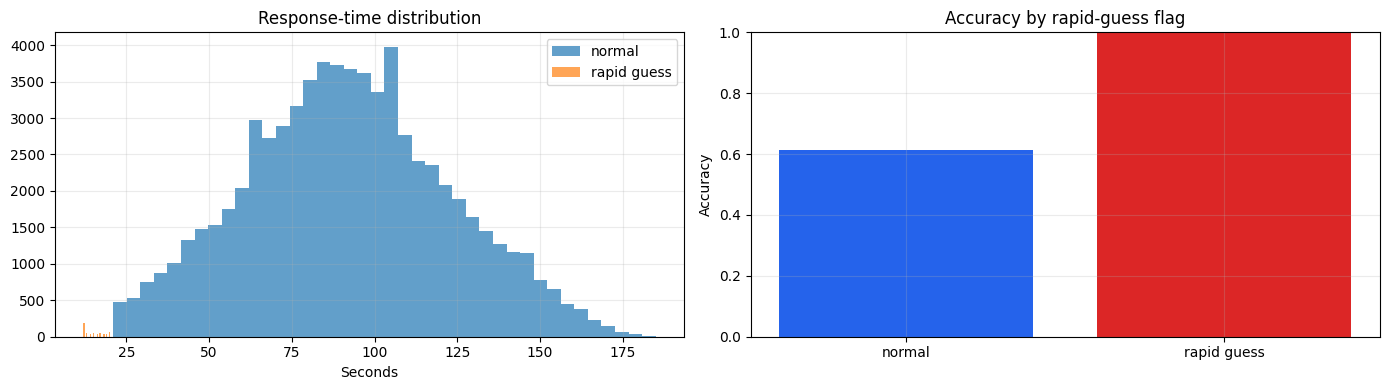

,rapid_guess_flag,n,accuracy,mean_response_time,mean_rapid_guess_penalty,mean_dars_test_delta,brier_dars
0,0,70124,0.612,91.8647,0.000,5.5167,0.2409
1,1,548,1.000,15.0620,4.829,-2.6022,0.0628


In [53]:
rapid_summary = (
    work.groupby("rapid_guess_flag")
    .agg(
        n=("correctness", "size"),
        accuracy=("correctness", "mean"),
        mean_response_time=("response_time", "mean"),
        mean_rapid_guess_penalty=("rapid_guess_penalty", "mean"),
        mean_dars_test_delta=("test_rating_delta", "mean"),
        brier_dars=("dars_prob", lambda p: brier_score(work.loc[p.index, "correctness"], p)),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(work.loc[work["rapid_guess_flag"].eq(0), "response_time"], bins=40, alpha=0.7, label="normal")
axes[0].hist(work.loc[work["rapid_guess_flag"].eq(1), "response_time"], bins=20, alpha=0.7, label="rapid guess")
axes[0].set_title("Response-time distribution")
axes[0].set_xlabel("Seconds")
axes[0].legend()

axes[1].bar(["normal", "rapid guess"], rapid_summary["accuracy"], color=["#2563eb", "#dc2626"])
axes[1].set_ylim(0, 1)
axes[1].set_title("Accuracy by rapid-guess flag")
axes[1].set_ylabel("Accuracy")
plt.tight_layout()
plt.show()

rapid_summary.round(4)


## Student-Level Outcomes and Prediction Snapshot Checks


In [54]:
student_metrics_rows = []
for user_id, frame in work.groupby("user_id"):
    if len(frame) < 10:
        continue
    row = {
        "user_id": user_id,
        "persona": frame["persona"].iloc[0],
        "evaluation_split": frame["evaluation_split"].iloc[0],
        "n_attempts": len(frame),
        "actual_accuracy": float(frame["correctness"].mean()),
        "rapid_guess_rate": float(frame["rapid_guess_flag"].mean()),
        "remediation_rate": float(frame["remediation_flag"].mean()),
        "avg_response_time": float(frame["response_time"].mean()),
        "final_dars_rating": float(frame["DARS_rating_after_test"].iloc[-1]),
        "final_glicko2_rating": final_glicko_states[user_id].rating,
        "final_glicko2_rd": final_glicko_states[user_id].rd,
        "final_fixed_elo_rating": final_elo_ratings[user_id],
    }
    for model, prob_col in MODEL_PROBS.items():
        metrics = metric_row(model, frame, prob_col)
        safe_name = model.lower().replace("+", "plus").replace(" ", "_").replace("=", "").replace("-", "_")
        row[f"{safe_name}_brier"] = metrics["brier"]
        row[f"{safe_name}_log_loss"] = metrics["log_loss"]
        row[f"{safe_name}_auc"] = metrics["roc_auc"]
    student_metrics_rows.append(row)

student_metrics = pd.DataFrame(student_metrics_rows)
snapshot_eval = snapshots.merge(student_metrics, on="user_id", how="left", validate="one_to_one")
snapshot_eval["predicted_score"] = pd.to_numeric(snapshot_eval["predicted_score"], errors="coerce")
snapshot_eval["score_like_actual"] = 100 * snapshot_eval["actual_accuracy"]
snapshot_eval["prediction_abs_error"] = (snapshot_eval["predicted_score"] - snapshot_eval["score_like_actual"]).abs()

student_metrics.to_csv(STUDENT_OUTPUT_CSV, index=False)

print("Snapshot predicted_score vs actual accuracy*100")
print(snapshot_eval[["predicted_score", "score_like_actual", "prediction_abs_error"]].describe().round(3))
student_metrics.sort_values("dars_brier").head(10).round(4)


Snapshot predicted_score vs actual accuracy*100
       predicted_score  score_like_actual  prediction_abs_error
count          220.000            220.000               220.000
mean            51.514             61.320                 9.905
std              4.010              5.405                 5.164
min             41.000             49.811                 0.154
25%             48.000             57.316                 6.250
50%             52.000             60.607                 9.951
75%             55.000             65.256                13.179
max             61.000             76.803                28.250


,user_id,persona,evaluation_split,n_attempts,actual_accuracy,rapid_guess_rate,remediation_rate,avg_response_time,final_dars_rating,final_glicko2_rating,...,dars_auc,glicko_2_brier,glicko_2_log_loss,glicko_2_auc,fixed_elo_k32_brier,fixed_elo_k32_log_loss,fixed_elo_k32_auc,static_start_brier,static_start_log_loss,static_start_auc
105,stu_fte455_106,steady_improver,train,319,0.7680,0.0000,0.2132,84.0345,1863.0,1647.0279,...,0.5783,0.1865,0.5653,0.5141,0.1807,0.5502,0.5423,0.1780,0.5396,0.5784
60,stu_fte455_061,steady_improver,train,395,0.7165,0.0000,0.2684,83.5620,1743.0,1634.3361,...,0.6618,0.1975,0.5785,0.6342,0.1932,0.5686,0.6507,0.1909,0.5636,0.6645
140,stu_fte455_141,steady_improver,train,309,0.7120,0.0000,0.2783,83.6246,1673.0,1613.4866,...,0.6554,0.1924,0.5670,0.6556,0.1945,0.5722,0.6480,0.1905,0.5630,0.6672
35,stu_fte455_036,steady_improver,train,262,0.7252,0.0000,0.2634,85.5878,1597.0,1593.8990,...,0.6725,0.1898,0.5599,0.6647,0.1894,0.5596,0.6564,0.2053,0.5978,0.6832
115,stu_fte455_116,steady_improver,train,435,0.7195,0.0000,0.2644,83.5149,1715.0,1582.5071,...,0.6266,0.1950,0.5794,0.6308,0.1943,0.5767,0.6262,0.1955,0.5769,0.6267
47,stu_fte455_048,slow_analytical,train,384,0.7266,0.0000,0.2552,101.6380,1807.0,1575.4736,...,0.6332,0.1934,0.5730,0.6329,0.1894,0.5652,0.6251,0.1871,0.5587,0.6476
195,stu_fte455_196,steady_improver,train,372,0.7097,0.0027,0.2715,82.6747,1756.0,1676.9878,...,0.6786,0.1994,0.5853,0.6393,0.1959,0.5794,0.6443,0.1959,0.5771,0.6401
200,stu_fte455_201,steady_improver,train,444,0.7252,0.0000,0.2658,79.7635,1662.0,1585.6808,...,0.6279,0.1942,0.5702,0.6378,0.1983,0.5805,0.6062,0.2130,0.6137,0.6344
114,stu_fte455_115,remediation_responder,train,315,0.6825,0.0000,0.3111,94.8603,1590.0,1599.7203,...,0.6591,0.2031,0.5925,0.6561,0.2063,0.6005,0.6308,0.2044,0.5957,0.6550
110,stu_fte455_111,steady_improver,train,263,0.7148,0.0000,0.2624,89.9848,1781.0,1541.1021,...,0.6349,0.1956,0.5786,0.6190,0.1959,0.5779,0.5991,0.1981,0.5858,0.6373


## Visual Summary


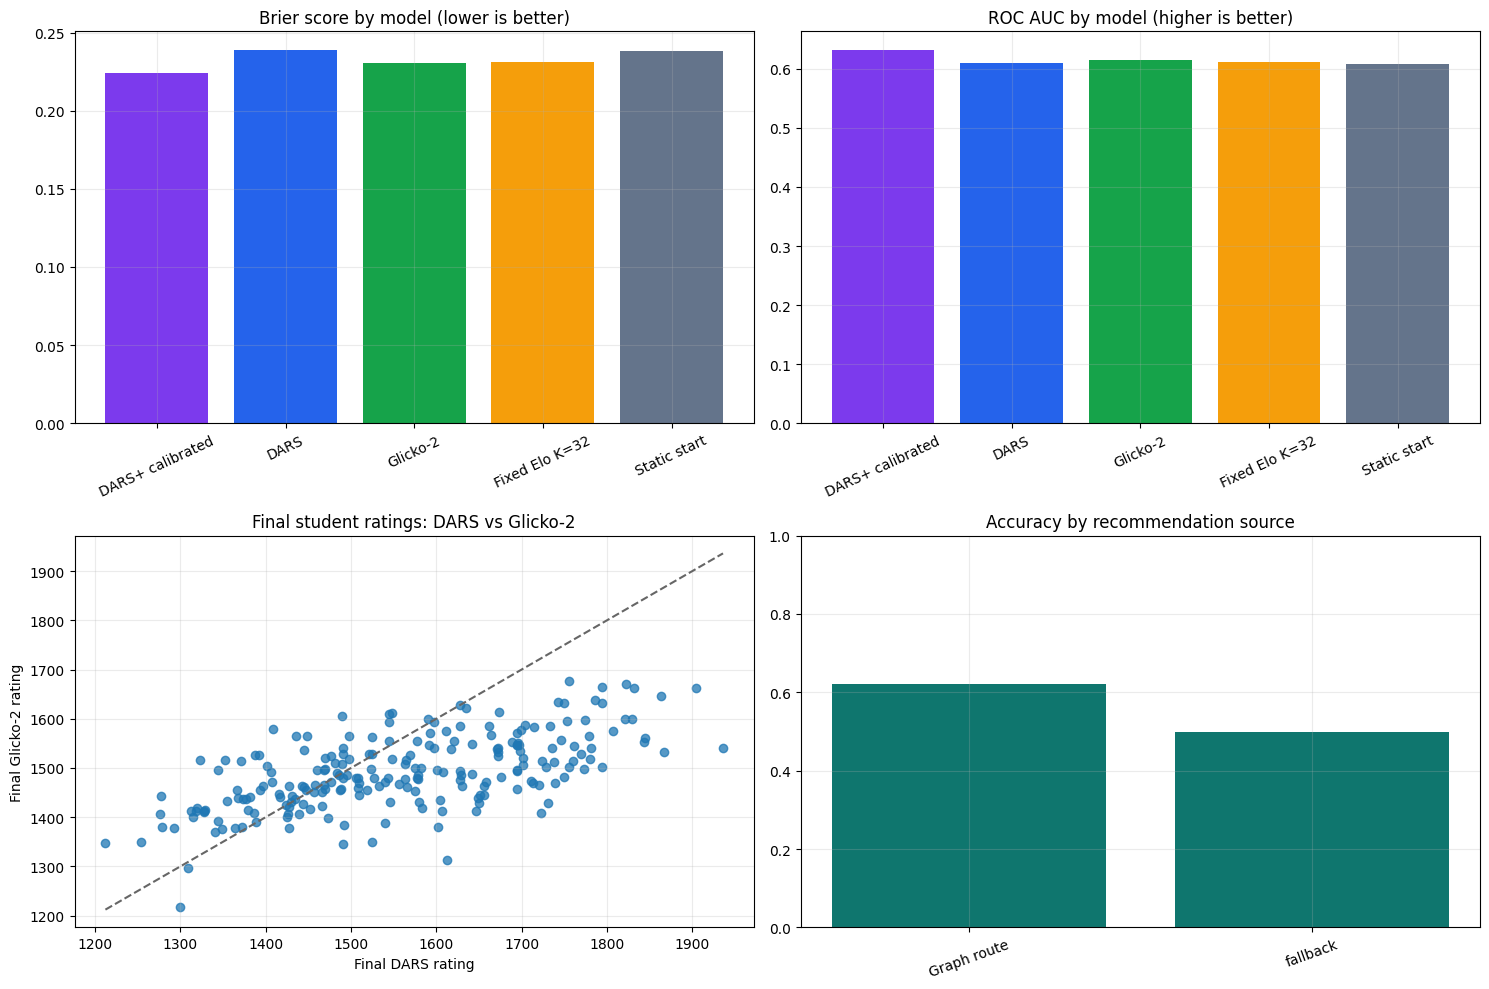

In [55]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metric_plot = overall_metrics.set_index("model").loc[list(MODEL_PROBS.keys())]
model_colors = ["#7c3aed", "#2563eb", "#16a34a", "#f59e0b", "#64748b"]
axes[0, 0].bar(metric_plot.index, metric_plot["brier"], color=model_colors)
axes[0, 0].set_title("Brier score by model (lower is better)")
axes[0, 0].tick_params(axis="x", rotation=25)

axes[0, 1].bar(metric_plot.index, metric_plot["roc_auc"], color=model_colors)
axes[0, 1].set_title("ROC AUC by model (higher is better)")
axes[0, 1].tick_params(axis="x", rotation=25)

axes[1, 0].scatter(student_metrics["final_dars_rating"], student_metrics["final_glicko2_rating"], alpha=0.75)
low = min(student_metrics["final_dars_rating"].min(), student_metrics["final_glicko2_rating"].min())
high = max(student_metrics["final_dars_rating"].max(), student_metrics["final_glicko2_rating"].max())
axes[1, 0].plot([low, high], [low, high], color="#666666", linestyle="--")
axes[1, 0].set_title("Final student ratings: DARS vs Glicko-2")
axes[1, 0].set_xlabel("Final DARS rating")
axes[1, 0].set_ylabel("Final Glicko-2 rating")

route_acc = question_route_coverage.set_index("recommendation_source")["accuracy"]
axes[1, 1].bar(route_acc.index.astype(str), route_acc.values, color="#0f766e")
axes[1, 1].set_ylim(0, 1)
axes[1, 1].set_title("Accuracy by recommendation source")
axes[1, 1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


## Report-Ready Interpretation Template


In [56]:
best_brier = overall_metrics.sort_values("brier").iloc[0]
best_auc = overall_metrics.sort_values("roc_auc", ascending=False).iloc[0]
dars_row = overall_metrics[overall_metrics["model"].eq("DARS")].iloc[0]
dars_plus_row = overall_metrics[overall_metrics["model"].eq("DARS+ calibrated")].iloc[0]
glicko_row = overall_metrics[overall_metrics["model"].eq("Glicko-2")].iloc[0]

print("Report-ready notes:")
print(f"- Best Brier score: {best_brier['model']} ({best_brier['brier']:.4f}).")
print(f"- Best ROC AUC: {best_auc['model']} ({best_auc['roc_auc']:.4f}).")
print(f"- DARS+ calibrated vs Glicko-2 Brier delta (Glicko - DARS+): {glicko_row['brier'] - dars_plus_row['brier']:.4f}.")
print(f"- DARS+ calibrated vs Glicko-2 log-loss delta (Glicko - DARS+): {glicko_row['log_loss'] - dars_plus_row['log_loss']:.4f}.")
print(f"- DARS vs Glicko-2 Brier delta (Glicko - DARS): {glicko_row['brier'] - dars_row['brier']:.4f}.")
print(f"- DARS vs Glicko-2 log-loss delta (Glicko - DARS): {glicko_row['log_loss'] - dars_row['log_loss']:.4f}.")
print(f"- Saved overall metrics: {SUMMARY_OUTPUT_CSV}")
print(f"- Saved segment metrics: {SEGMENT_OUTPUT_CSV}")
print(f"- Saved student metrics: {STUDENT_OUTPUT_CSV}")
print(f"- Saved graph metrics: {GRAPH_OUTPUT_CSV}")
print(f"- Saved remediation metrics: {REMEDIATION_OUTPUT_CSV}")
print(f"- Saved bootstrap CIs: {BOOTSTRAP_OUTPUT_CSV}")


Report-ready notes:
- Best Brier score: DARS+ calibrated (0.2244).
- Best ROC AUC: DARS+ calibrated (0.6319).
- DARS+ calibrated vs Glicko-2 Brier delta (Glicko - DARS+): 0.0064.
- DARS+ calibrated vs Glicko-2 log-loss delta (Glicko - DARS+): 0.0153.
- DARS vs Glicko-2 Brier delta (Glicko - DARS): -0.0080.
- DARS vs Glicko-2 log-loss delta (Glicko - DARS): -0.0276.
- Saved overall metrics: c:\Users\sunil\Downloads\btech-project\datasets\dars\dars_all_model_metrics.csv
- Saved segment metrics: c:\Users\sunil\Downloads\btech-project\datasets\dars\dars_all_segment_metrics.csv
- Saved student metrics: c:\Users\sunil\Downloads\btech-project\datasets\dars\dars_all_student_metrics.csv
- Saved graph metrics: c:\Users\sunil\Downloads\btech-project\datasets\dars\dars_graph_routing_metrics.csv
- Saved remediation metrics: c:\Users\sunil\Downloads\btech-project\datasets\dars\dars_remediation_metrics.csv
- Saved bootstrap CIs: c:\Users\sunil\Downloads\btech-project\datasets\dars\dars_model_metric_b

## How to Use This in the Paper

Use the overall predictive metrics for the main DARS-vs-baseline table. Use segment metrics to support claims about DARS behavior under momentum, remediation, graph routing, rapid guesses, and difficulty bands. Use the convergence plot as evidence for the dynamic-rating behavior discussed in the DARS paper, but label it carefully as a simulated-dataset validation until real learner logs are included.
